# Figure 3 of Pierard2024TheTile: the Tile

In [1]:
import math

import matplotlib.pyplot as plt

from sorbetto.annotation import (
    AnnotationCurveFixedClassPriors,
    AnnotationCurveFixedPredictionRates,
    AnnotationGeometric,
    AnnotationText,
)
from sorbetto.parameterization import ParameterizationDefault
from sorbetto.ranking import (
    Importance,
    PerformanceOrderingsInducedByRankingScores,
    RankingScore,
)
from sorbetto.tile import Tile

## Placement of the canonical ranking scores

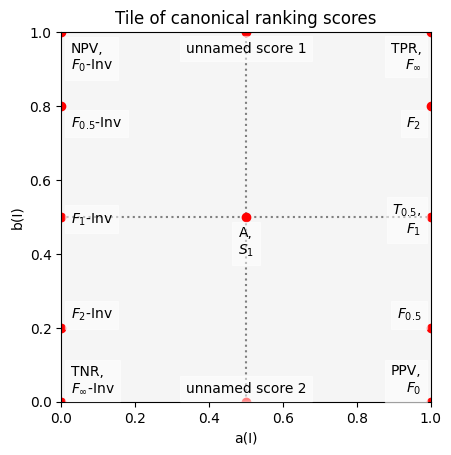

In [2]:
scores = [
    RankingScore.getTrueNegativeRate(),
    RankingScore.getTruePositiveRate(),
    RankingScore.getNegativePredictiveValue(),
    RankingScore.getPositivePredictiveValue(),
    RankingScore.getAccuracy(),
    RankingScore.getSimilarityCoefficientsS(theta=1.0),
    RankingScore.getSimilarityCoefficientsT(theta=0.5),
    RankingScore(Importance(0.5, 0.0, 1.0, 0.5), name="unnamed score 1"),
    RankingScore(Importance(0.5, 1.0, 0.0, 0.5), name="unnamed score 2"),
]
for beta in [0.0, 0.5, 1.0, 2.0, math.inf]:
    scores.append(RankingScore.getF(beta=beta))
    scores.append(RankingScore.getInverseF(beta=beta))

parameterization = ParameterizationDefault()
tile = Tile(parameterization, name="Tile of canonical ranking scores")

locus = tile.parameterization.locateRelativeImportanceUnsatisfying(0.5, 0.5)
annotation = AnnotationGeometric(locus, linestyle=":", color="grey")
tile.appendAnnotation(annotation)

locus = tile.parameterization.locateRelativeImportanceSatisfying(0.5, 0.5)
annotation = AnnotationGeometric(locus, linestyle=":", color="grey")
tile.appendAnnotation(annotation)

for score in scores:
    annotation = AnnotationText(
        score, markerfacecolor="red", color="black", markeredgecolor="red"
    )
    tile.appendAnnotation(annotation)

tile.draw()
plt.show()
# print ( tile.getExplanation () )

## Placement of performance orderings, without any constraint

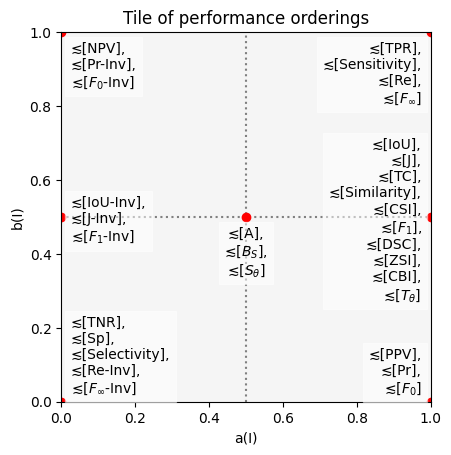

In [3]:
orderings = [
    PerformanceOrderingsInducedByRankingScores.getTrueNegativeRate(),
    PerformanceOrderingsInducedByRankingScores.getTruePositiveRate(),
    PerformanceOrderingsInducedByRankingScores.getSpecificity(),
    PerformanceOrderingsInducedByRankingScores.getSelectivity(),
    PerformanceOrderingsInducedByRankingScores.getSensitivity(),
    PerformanceOrderingsInducedByRankingScores.getNegativePredictiveValue(),
    PerformanceOrderingsInducedByRankingScores.getPositivePredictiveValue(),
    PerformanceOrderingsInducedByRankingScores.getPrecision(),
    PerformanceOrderingsInducedByRankingScores.getInversePrecision(),
    PerformanceOrderingsInducedByRankingScores.getRecall(),
    PerformanceOrderingsInducedByRankingScores.getInverseRecall(),
    PerformanceOrderingsInducedByRankingScores.getIntersectionOverUnion(),
    PerformanceOrderingsInducedByRankingScores.getInverseIntersectionOverUnion(),
    PerformanceOrderingsInducedByRankingScores.getJaccard(),
    PerformanceOrderingsInducedByRankingScores.getInverseJaccard(),
    PerformanceOrderingsInducedByRankingScores.getTanimotoCoefficient(),
    PerformanceOrderingsInducedByRankingScores.getSimilarity(),
    PerformanceOrderingsInducedByRankingScores.getCriticalSuccessIndex(),
    PerformanceOrderingsInducedByRankingScores.getF(beta=0.0),
    PerformanceOrderingsInducedByRankingScores.getInverseF(beta=0.0),
    PerformanceOrderingsInducedByRankingScores.getF(beta=1.0),
    PerformanceOrderingsInducedByRankingScores.getInverseF(beta=1.0),
    PerformanceOrderingsInducedByRankingScores.getF(beta=math.inf),
    PerformanceOrderingsInducedByRankingScores.getInverseF(beta=math.inf),
    PerformanceOrderingsInducedByRankingScores.getDiceSorensenCoefficient(),
    PerformanceOrderingsInducedByRankingScores.getZijdenbosSimilarityIndex(),
    PerformanceOrderingsInducedByRankingScores.getCzekanowskiBinaryIndex(),
    PerformanceOrderingsInducedByRankingScores.getAccuracy(),
    PerformanceOrderingsInducedByRankingScores.getBennettS(),
    PerformanceOrderingsInducedByRankingScores.getSimilarityCoefficientsT(),
    PerformanceOrderingsInducedByRankingScores.getSimilarityCoefficientsS(),
]

parameterization = ParameterizationDefault()
tile = Tile(parameterization, name="Tile of performance orderings")

locus = tile.parameterization.locateRelativeImportanceUnsatisfying(0.5, 0.5)
annotation = AnnotationGeometric(locus, linestyle=":", color="grey")
tile.appendAnnotation(annotation)

locus = tile.parameterization.locateRelativeImportanceSatisfying(0.5, 0.5)
annotation = AnnotationGeometric(locus, linestyle=":", color="grey")
tile.appendAnnotation(annotation)

for ordering in orderings:
    annotation = AnnotationText(
        ordering, markerfacecolor="red", color="black", markeredgecolor="red"
    )
    tile.appendAnnotation(annotation)

tile.draw()
plt.show()
# print ( tile.getExplanation () )

## Placement of performance orderings, with fixed class priors

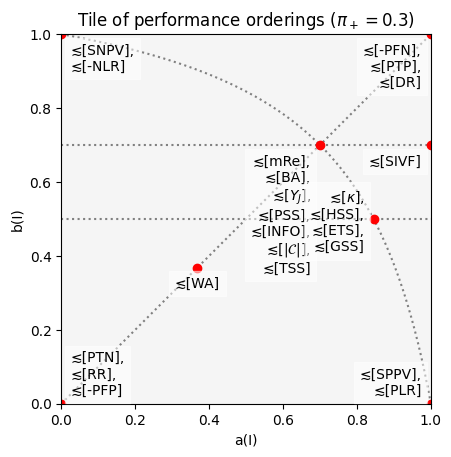

In [4]:
priorPos = 0.3

orderings = [
    PerformanceOrderingsInducedByRankingScores.getStandardizedNegativePredictiveValue(
        priorPos
    ),
    PerformanceOrderingsInducedByRankingScores.getStandardizedPositivePredictiveValue(
        priorPos
    ),
    PerformanceOrderingsInducedByRankingScores.getNegativeLikelihoodRatioComplement(
        priorPos
    ),
    PerformanceOrderingsInducedByRankingScores.getPositiveLikelihoodRatio(priorPos),
    PerformanceOrderingsInducedByRankingScores.getSkewInsensitiveVersionOfF1(priorPos),
    PerformanceOrderingsInducedByRankingScores.getWeightedAccuracy(
        priorPos, weightPos=0.2
    ),
    PerformanceOrderingsInducedByRankingScores.getMacroAveragedRecall(priorPos),
    PerformanceOrderingsInducedByRankingScores.getBalancedAccuracy(priorPos),
    PerformanceOrderingsInducedByRankingScores.getYoudenJ(priorPos),
    PerformanceOrderingsInducedByRankingScores.getPeirceSkillScore(priorPos),
    PerformanceOrderingsInducedByRankingScores.getInformedness(priorPos),
    PerformanceOrderingsInducedByRankingScores.getCohenKappa(priorPos=priorPos),
    PerformanceOrderingsInducedByRankingScores.getHeidkeSkillScore(priorPos=priorPos),
    PerformanceOrderingsInducedByRankingScores.getEquitableThreatScore(
        priorPos=priorPos
    ),
    PerformanceOrderingsInducedByRankingScores.getGilbertSkillScore(priorPos=priorPos),
    PerformanceOrderingsInducedByRankingScores.getProbabilityTrueNegative(
        priorPos=priorPos
    ),
    PerformanceOrderingsInducedByRankingScores.getRejectionRate(priorPos=priorPos),
    PerformanceOrderingsInducedByRankingScores.getProbabilityFalsePositiveComplement(
        priorPos=priorPos
    ),
    PerformanceOrderingsInducedByRankingScores.getProbabilityFalseNegativeComplement(
        priorPos=priorPos
    ),
    PerformanceOrderingsInducedByRankingScores.getProbabilityTruePositive(
        priorPos=priorPos
    ),
    PerformanceOrderingsInducedByRankingScores.getDetectionRate(priorPos=priorPos),
    PerformanceOrderingsInducedByRankingScores.getNormalizedConfusionMatrixDeterminant(
        priorPos=priorPos
    ),
    PerformanceOrderingsInducedByRankingScores.getTrueSkillStatistic(priorPos=priorPos),
]

parameterization = ParameterizationDefault()
tile = Tile(
    parameterization,
    name=r"Tile of performance orderings ($\pi_+={:g}$)".format(priorPos),
)

locus = tile.parameterization.locateRelativeImportanceUnsatisfying(0.5, 0.5)
annotation = AnnotationGeometric(locus, linestyle=":", color="grey")
tile.appendAnnotation(annotation)

locus = tile.parameterization.locateRelativeImportanceUnsatisfying(
    priorPos, 1.0 - priorPos
)
annotation = AnnotationGeometric(locus, linestyle=":", color="grey")
tile.appendAnnotation(annotation)

locus = tile.parameterization.locateOrderingsInvertedWithOpChangePredictedClass()
annotation = AnnotationGeometric(locus, linestyle=":", color="grey")
tile.appendAnnotation(annotation)

annotation = AnnotationCurveFixedClassPriors(priorPos, linestyle=":", color="grey")
tile.appendAnnotation(annotation)

for ordering in orderings:
    annotation = AnnotationText(
        ordering, markerfacecolor="red", color="black", markeredgecolor="red"
    )
    tile.appendAnnotation(annotation)

tile.draw()
plt.show()
# print ( tile.getExplanation () )

## Placement of performance orderings, with fixed prediction rates

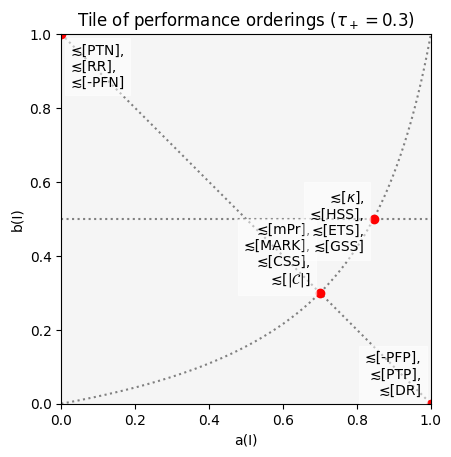

In [5]:
ratePos = 0.3

orderings = [
    PerformanceOrderingsInducedByRankingScores.getProbabilityTrueNegative(
        ratePos=ratePos
    ),
    PerformanceOrderingsInducedByRankingScores.getRejectionRate(ratePos=ratePos),
    PerformanceOrderingsInducedByRankingScores.getProbabilityFalsePositiveComplement(
        ratePos=ratePos
    ),
    PerformanceOrderingsInducedByRankingScores.getProbabilityFalseNegativeComplement(
        ratePos=ratePos
    ),
    PerformanceOrderingsInducedByRankingScores.getProbabilityTruePositive(
        ratePos=ratePos
    ),
    PerformanceOrderingsInducedByRankingScores.getDetectionRate(ratePos=ratePos),
    PerformanceOrderingsInducedByRankingScores.getMacroAveragedPrecision(ratePos),
    PerformanceOrderingsInducedByRankingScores.getMarkedness(ratePos),
    PerformanceOrderingsInducedByRankingScores.getCohenKappa(ratePos=ratePos),
    PerformanceOrderingsInducedByRankingScores.getHeidkeSkillScore(ratePos=ratePos),
    PerformanceOrderingsInducedByRankingScores.getEquitableThreatScore(ratePos=ratePos),
    PerformanceOrderingsInducedByRankingScores.getGilbertSkillScore(ratePos=ratePos),
    PerformanceOrderingsInducedByRankingScores.getClaytonSkillScore(ratePos),
    PerformanceOrderingsInducedByRankingScores.getNormalizedConfusionMatrixDeterminant(
        ratePos=ratePos
    ),
]

parameterization = ParameterizationDefault()
tile = Tile(
    parameterization,
    name=r"Tile of performance orderings ($\tau_+={:g}$)".format(ratePos),
)

locus = tile.parameterization.locateRelativeImportanceUnsatisfying(0.5, 0.5)
annotation = AnnotationGeometric(locus, linestyle=":", color="grey")
tile.appendAnnotation(annotation)

locus = tile.parameterization.locateOrderingsInvertedWithOpChangeGroundtruthClass()
annotation = AnnotationGeometric(locus, linestyle=":", color="grey")
tile.appendAnnotation(annotation)

annotation = AnnotationCurveFixedPredictionRates(ratePos, linestyle=":", color="grey")
tile.appendAnnotation(annotation)

for ordering in orderings:
    annotation = AnnotationText(
        ordering, markerfacecolor="red", color="black", markeredgecolor="red"
    )
    tile.appendAnnotation(annotation)

tile.draw()
plt.show()
# print ( tile.getExplanation () )